# Machine Learning Architectures: What Is Inside the Models

In module M2 you trained models on the Titanic dataset and compared their scores. You treated each model as a **black box**: data in, predictions out, tune the knobs. Today we open the boxes. You will see exactly what a linear model, a decision tree, and a neural network look like on the inside, watch each one "think" by drawing its decisions on a map, and learn how to pick the right architecture for a problem.

**What you will learn:**

- What "architecture" means: the blueprint that decides what shapes a model can learn
- How logistic regression is just a weighted scorecard
- How decision trees, random forests, and gradient boosting really work
- How to build a single neuron with plain numpy, and grow it into a neural network
- How training works: loss functions and gradient descent, explained simply
- What CNNs, RNNs, and Transformers are (the architectures behind image AI and ChatGPT)
- How to choose an architecture for a new problem
- How a trained model fits into a real software system (the bridge to deployment)


## How to run this notebook

This notebook works in two places, and you do not need any account or API key:

- **Locally with Jupyter:** open a terminal, run `jupyter lab` (or `jupyter notebook`), and open this file.
- **Google Colab:** go to [colab.research.google.com](https://colab.research.google.com), choose *File > Upload notebook*, and pick this file.

Run the cells **top to bottom**. The setup cell below installs anything that is missing. On Colab everything is usually already installed, so it finishes instantly. All the data we use ships with scikit-learn itself, so nothing is downloaded from the internet.


In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("numpy"); ensure("pandas"); ensure("matplotlib"); ensure("sklearn", "scikit-learn")

## 1. What "architecture" means

An **architecture** is the blueprint of a model: it decides *what shape* the learned function can have.

Every supervised model does the same job: it learns a function that maps inputs to an output (features in, prediction out). But different architectures can only learn different *shapes* of function:

- A **linear model** can only draw a straight line (or a flat plane) to separate classes.
- A **tree** can only draw boundaries made of horizontal and vertical cuts (rectangles).
- A **neural network** can draw smooth curves of almost any shape.

In M2 we compared models **from the outside**: we looked at accuracy scores and picked a winner. Today we look **inside**. By the end you will know *why* one model wins on one dataset and loses on another - it is usually because the shape of the problem matches (or does not match) the shape the architecture can draw.

Here is the map for today. Three big families:

| Family | Core idea | Examples |
|---|---|---|
| Linear models | A weighted sum of the features | Linear regression, logistic regression |
| Tree-based models | A flowchart of yes/no questions | Decision tree, random forest, gradient boosting |
| Neural networks | Layers of tiny units, each doing a weighted sum + a squash | MLP, CNN, Transformer |

We open each one, in that order.


## 2. Our playground: the two moons dataset

To *see* how each architecture thinks, we need a dataset we can draw. So we use **make_moons**, a toy dataset built into scikit-learn: 400 points, only **2 features** (so every point fits on a flat plot), and 2 classes shaped like two interleaving crescent moons.

Why this dataset? Because the two moons **cannot be separated by a straight line**. That makes it the perfect stress test: it will expose exactly what each architecture can and cannot do.

Let's generate it and look at it. As always, `random_state=42` makes the result reproducible.


X shape: (400, 2) -> 400 points, 2 features each
y shape: (400,) -> one label (0 or 1) per point


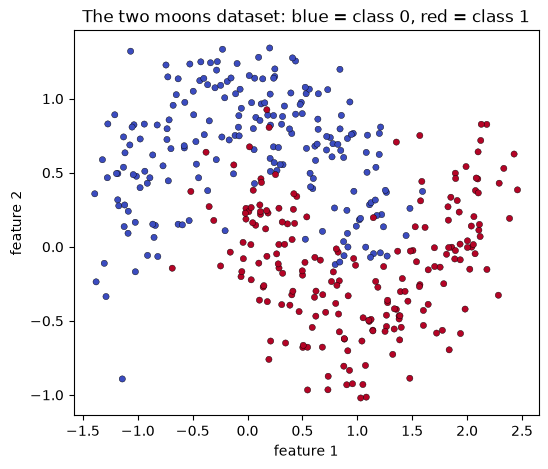

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

print("X shape:", X.shape, "-> 400 points, 2 features each")
print("y shape:", y.shape, "-> one label (0 or 1) per point")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=20, edgecolor="k", linewidth=0.3)
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("The two moons dataset: blue = class 0, red = class 1")
plt.show()

### A reusable tool: drawing a decision boundary

A **decision boundary** is the line where a model switches from predicting one class to predicting the other. We will draw it with a **meshgrid**. The idea takes three sentences:

1. Cover the whole plot area with a fine grid of thousands of points, like pixels on a screen.
2. Ask the model to predict a class for *every* grid point.
3. Color each point by its prediction - the colored regions show where the model "believes" each class lives, and the edge between colors is the decision boundary.

We wrap this in a helper function so we can reuse it for every model in this notebook. Same data, same colors, every time - so the *only* thing that changes between plots is the architecture.


In [3]:
def plot_decision_boundary(model, X, y, ax, title):
    """Color every point of the map by what the model would predict there."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]          # every grid point as (x, y)
    Z = model.predict(grid).reshape(xx.shape)     # one prediction per grid point
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=15,
               edgecolor="k", linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

print("Helper ready. Every model below gets drawn with this exact function.")

Helper ready. Every model below gets drawn with this exact function.


## 3. Linear models, opened up

**Logistic regression** (from M2) is the simplest architecture. Inside, it is just a **weighted scorecard**:

```
score = w1 * x1 + w2 * x2 + b
```

- `w1`, `w2` are the **weights**: how much each feature matters (these are learned from data).
- `b` is the **bias** (also called intercept): the starting score before looking at any feature.
- The score is then pushed through a **sigmoid** - a squashing function that turns any number into a value between 0 and 1, which we read as a probability.

That is the whole model. Two multiplications, one addition, one squash. Let's train it on the moons and print the actual learned numbers.


In [4]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)

w1, w2 = log_reg.coef_[0]
b = log_reg.intercept_[0]
print(f"Learned weight w1 (for feature 1): {w1:+.3f}")
print(f"Learned weight w2 (for feature 2): {w2:+.3f}")
print(f"Learned bias b:                    {b:+.3f}")
print()
print(f"So the model is:  score = {w1:.2f} * x1 + {w2:.2f} * x2 + {b:.2f}")
print("If score > 0 the model says class 1, otherwise class 0.")

Learned weight w1 (for feature 1): +1.179
Learned weight w2 (for feature 2): -3.372
Learned bias b:                    +0.254

So the model is:  score = 1.18 * x1 + -3.37 * x2 + 0.25
If score > 0 the model says class 1, otherwise class 0.


### Reading the scorecard aloud

Look at the numbers above (yours should match, since everything is seeded):

- **w2 is about -3.4**, a big negative weight. In plain words: *the higher a point sits (large feature 2), the more the model leans toward class 0 (blue)*. That matches the picture - the blue moon is mostly on top.
- **w1 is about +1.2**, a moderate positive weight: *points further to the right lean toward class 1 (red)*.
- **b is about +0.25**: a small head start for class 1 before looking at anything.

This is the superpower of linear models: you can read the learned model like a sentence. That is why banks and hospitals still love them.

Now let's look at the **sigmoid**, the squashing function that turns the score into a probability.


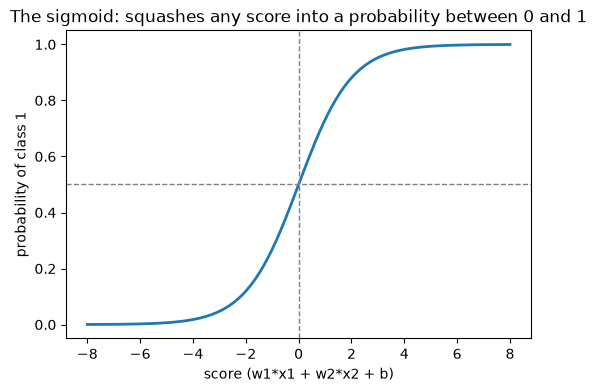

score = 0   -> probability 0.5 (the model is unsure)
big positive score -> probability near 1 (confident class 1)
big negative score -> probability near 0 (confident class 0)


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z, sigmoid(z), linewidth=2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("score (w1*x1 + w2*x2 + b)")
ax.set_ylabel("probability of class 1")
ax.set_title("The sigmoid: squashes any score into a probability between 0 and 1")
plt.show()

print("score = 0   -> probability 0.5 (the model is unsure)")
print("big positive score -> probability near 1 (confident class 1)")
print("big negative score -> probability near 0 (confident class 0)")

### The linear boundary on the moons - and why it struggles

A weighted scorecard `w1*x1 + w2*x2 + b = 0` is the equation of a **straight line**. So the decision boundary of logistic regression is *always* a straight line, no matter how much data you give it. Let's draw it.


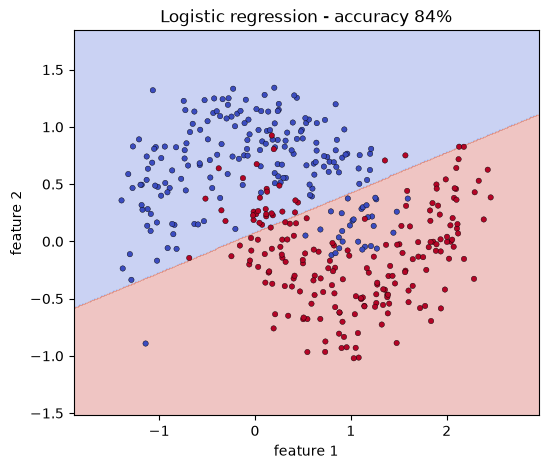

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(log_reg, X, y, ax,
                       f"Logistic regression - accuracy {log_reg.score(X, y):.0%}")
plt.show()

The model does its best: one straight cut, about 84% correct. But look at the tips of the moons - the red crescent hooks *under* the blue one, and no straight line can follow that hook. This is not a tuning problem. You could train forever and it would never get much better, because **the architecture cannot draw the shape the data needs**.

That is the most important lesson of this notebook: *a model can only learn shapes its architecture allows.*

## 4. Tree-based models, opened up

A **decision tree** is a flowchart of yes/no questions about the features. Prediction is just walking the flowchart: start at the top, answer each question, and the leaf you land in gives the answer.

Unlike the scorecard, a tree never multiplies or adds features. It only asks *"is feature j smaller than some threshold?"* over and over. The training algorithm picks the questions: at each step it tries every possible split and keeps the one that best separates the classes.

Let's fit a small tree (limited to 3 levels of questions) and look at the **actual flowchart it learned**.


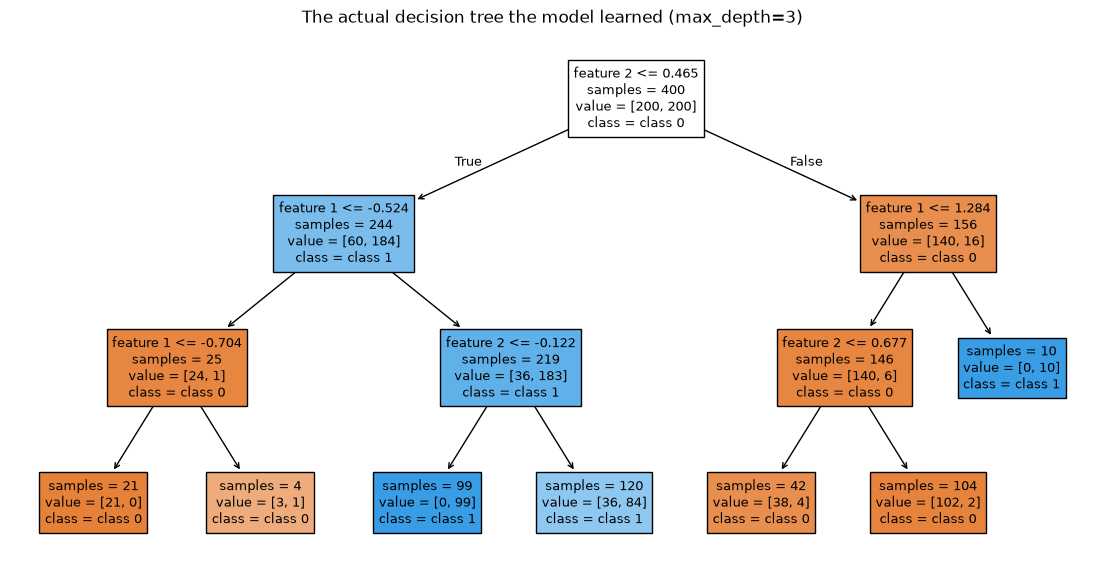

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(tree, feature_names=["feature 1", "feature 2"],
          class_names=["class 0", "class 1"], filled=True,
          impurity=False, fontsize=9, ax=ax)
ax.set_title("The actual decision tree the model learned (max_depth=3)")
plt.show()

### Walking one path in words

Read the flowchart from the top. In each box, if the condition is **True** go **left**, if **False** go **right**. Follow one real path with me (the numbers below come from the tree you just trained):

- Root: *"Is feature 2 <= 0.46?"* - **yes**, our point sits low on the map, go left.
- Next: *"Is feature 1 <= -0.52?"* - **no**, our point is not that far left, go right.
- One more question about feature 2, and both leaves down there say **class 1**.

In plain words the tree learned: *"if a point sits low and is not too far left, it belongs to the red moon"*. Which is true - look back at the scatter plot.

Every leaf also shows `samples` (how many training points ended there) and `value` (how many of each class). A leaf with `value = [3, 58]` is very confident: 58 red points and only 3 blue ones landed there.

Because every question is "one feature vs one threshold", each question cuts the map with a horizontal or vertical line. Stack the questions and you get a boundary made of **rectangles**:


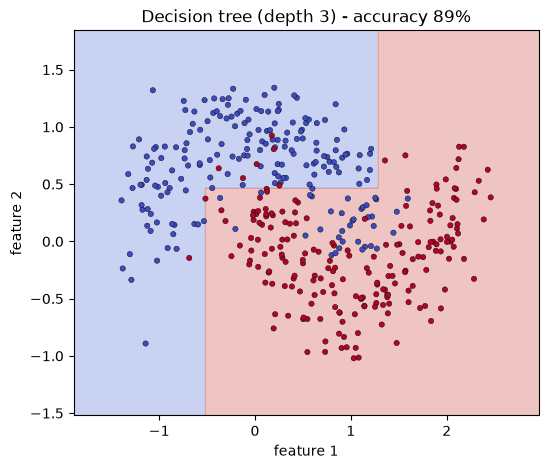

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(tree, X, y, ax,
                       f"Decision tree (depth 3) - accuracy {tree.score(X, y):.0%}")
plt.show()

Blocky, but already better than the straight line - the rectangles can follow the hooks of the moons, roughly.

### Overfitting, seen with your own eyes

In M2 you learned that **overfitting** means memorizing the training data instead of learning the pattern. With 2D data we can literally *see* it. Compare a shallow tree (depth 2) with a very deep one (depth 20):


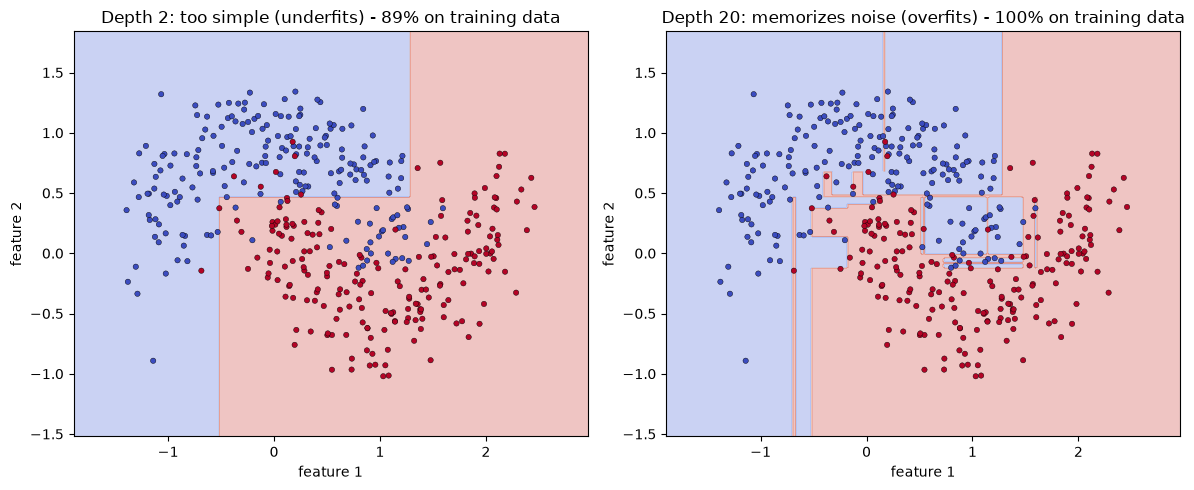

In [9]:
shallow = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X, y)
deep = DecisionTreeClassifier(max_depth=20, random_state=42).fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(shallow, X, y, axes[0],
                       f"Depth 2: too simple (underfits) - {shallow.score(X, y):.0%} on training data")
plot_decision_boundary(deep, X, y, axes[1],
                       f"Depth 20: memorizes noise (overfits) - {deep.score(X, y):.0%} on training data")
plt.tight_layout()
plt.show()

The depth-20 tree scores 100% on the training data - but look at the map. It carved out a tiny rectangle around every single noisy point. Those slivers are *memorized noise*, and they will be wrong for new data. The depth-2 tree is honest but too crude. The sweet spot is in between - or better: use **many trees**.

### Random forest: a crowd of trees that votes

A **random forest** trains many trees (here 100) and lets them **vote**. Two tricks make the trees different from each other:

- **Bagging**: each tree trains on a random re-sample of the data (some points repeated, some left out).
- Each split only considers a random subset of the features.

Intuition: *100 trees, each sees a shuffled sample, they vote - and their individual errors cancel out.* One tree's memorized noise-sliver is outvoted by 99 trees that never saw that noise.


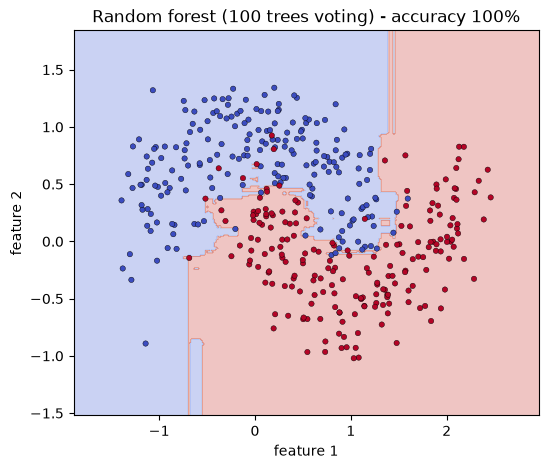

In [10]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X, y)

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(forest, X, y, ax,
                       f"Random forest (100 trees voting) - accuracy {forest.score(X, y):.0%}")
plt.show()

Still made of tiny rectangles (it is trees all the way down), but the *average of 100 opinions* gives a much smoother, more sensible boundary than any single deep tree.

### Gradient boosting: trees that fix each other's mistakes

**Gradient boosting** also builds many trees, but not in parallel - **in sequence**. Each new tree is trained to fix the mistakes the team has made so far: tree 1 makes a rough guess, tree 2 focuses on the points tree 1 got wrong, tree 3 fixes what is still wrong, and so on. The final prediction adds all the small corrections together. On tabular business data (spreadsheet-like data), this family - XGBoost, LightGBM, sklearn's GradientBoosting - wins most competitions.


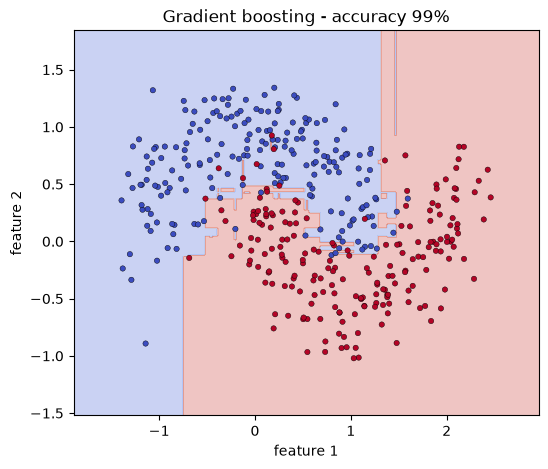

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

boost = GradientBoostingClassifier(random_state=42)
boost.fit(X, y)

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(boost, X, y, ax,
                       f"Gradient boosting - accuracy {boost.score(X, y):.0%}")
plt.show()

Smooth *and* accurate. Boosting earns its reputation.

## 5. Neural networks, from a single neuron up

Neural networks sound intimidating. They are not. We will build one bottom-up, starting from a single **neuron** - and a neuron is something you already know: it is the *same weighted scorecard* from section 3.

### 5a. One neuron, by hand

A neuron does exactly two things:

1. Compute a weighted sum of its inputs plus a bias: `z = w1*x1 + w2*x2 + b`
2. Push the result through an **activation function** (a simple squashing function).

That is all. Here it is in six lines of plain numpy - no library magic:


In [12]:
x = np.array([2.0, 3.0])        # the input: one data point with 2 features
w = np.array([0.5, -1.0])       # the neuron's weights (learned during training)
b = 0.1                         # the neuron's bias
z = w @ x + b                   # step 1: weighted sum  (0.5*2.0 + -1.0*3.0 + 0.1)
output = 1 / (1 + np.exp(-z))   # step 2: activation (sigmoid squash)
print(f"z = {z:.2f}   ->   neuron output = {output:.3f}")

z = -1.90   ->   neuron output = 0.130


A weighted sum and a squash. Logistic regression *is* a single neuron. Everything that follows is just: **use many neurons, stacked in layers.**

### 5b. Activation functions: the source of all the magic

An **activation function** is the small nonlinear squash applied after the weighted sum. The three classics:

- **Sigmoid**: squashes to (0, 1). Used at the *output* when you need a probability.
- **Tanh**: squashes to (-1, 1). Zero-centered; common in older networks and RNNs.
- **ReLU** ("rectified linear unit"): `max(0, z)` - keeps positives, zeroes out negatives. The default choice for hidden layers in modern networks because it is fast and trains well.

Why do we need them at all? Because **without a nonlinearity, stacking layers is pointless**: a weighted sum of weighted sums is still just one weighted sum - one straight line, no matter how many layers you stack. The little squash between layers is what lets the network bend lines into curves.


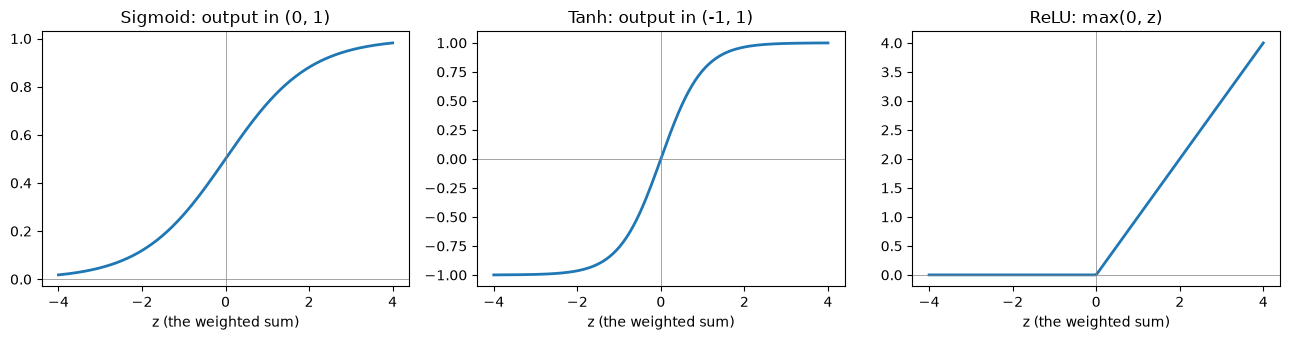

In [13]:
z = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(z, 1 / (1 + np.exp(-z)), linewidth=2)
axes[0].set_title("Sigmoid: output in (0, 1)")
axes[1].plot(z, np.tanh(z), linewidth=2)
axes[1].set_title("Tanh: output in (-1, 1)")
axes[2].plot(z, np.maximum(0, z), linewidth=2)
axes[2].set_title("ReLU: max(0, z)")
for ax in axes:
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("z (the weighted sum)")
plt.tight_layout()
plt.show()

### 5c. Layers: neurons stacked into a network

Put neurons side by side to form a **layer**. Connect layers front to back and you have a network. Every neuron in a layer receives *all* outputs of the previous layer:

```
 INPUT           HIDDEN           HIDDEN          OUTPUT
 LAYER           LAYER 1          LAYER 2         LAYER

 x1 ----.        ( n )            ( n )
         \      /( n )\          /( n )\
          >----<  ( n ) >------<   ( n ) >-----( n )---> probability
         /      \( n )/          \( n )/
 x2 ----'        ( n )            ( n )

 2 features      each (n) = weighted sum + activation     1 answer
```

- The **input layer** is just the features (no computation).
- Each **hidden layer** transforms the data a little: bend, stretch, fold.
- The **output layer** produces the final answer.

**Deep learning** simply means: a neural network with many hidden layers. Nothing more mysterious than that. Each extra layer lets the network build more complicated shapes out of the simpler shapes the previous layer made.

### 5d. How training works, in plain words

Where do all those weights come from? Training. Two ideas:

- **Loss function**: a single number measuring *"how wrong are we right now?"* Big loss = bad predictions, zero loss = perfect. Definition done.
- **Gradient descent**: the algorithm that reduces the loss. Imagine standing on a hillside in fog. You cannot see the valley, but you can *feel the slope under your feet*. So you take a small step downhill. Then feel again. Step again. Repeat thousands of times and you walk to the bottom - the weights with the smallest loss.

The "slope" is called the **gradient** (hence the name), and the step size is the **learning rate**. Let's watch gradient descent walk downhill on the simplest possible example: one weight `w`, loss `(w - 3)^2`. The best value is obviously `w = 3` - let's see the algorithm find it on its own.


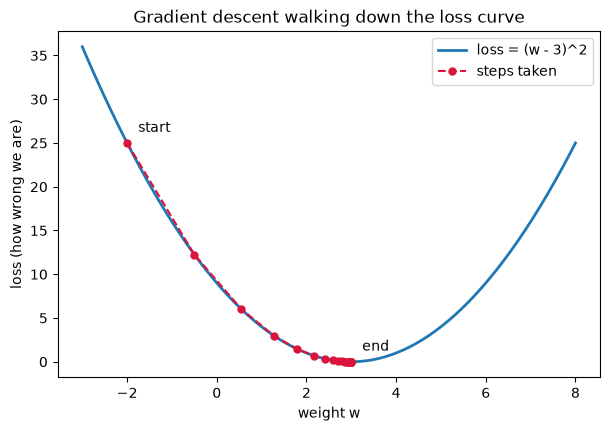

Started at w = -2.00, ended at w = 2.9960  (true best: 3.0)


In [14]:
loss = lambda w: (w - 3) ** 2       # how wrong are we? (best possible: w = 3)
slope = lambda w: 2 * (w - 3)       # the gradient: derivative of the loss

w = -2.0                            # start far from the answer, on purpose
learning_rate = 0.15
path = [w]
for step in range(20):
    w = w - learning_rate * slope(w)    # step downhill, against the slope
    path.append(w)

path = np.array(path)
w_axis = np.linspace(-3, 8, 200)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(w_axis, loss(w_axis), linewidth=2, label="loss = (w - 3)^2")
ax.plot(path, loss(path), "o--", color="crimson", markersize=5, label="steps taken")
ax.annotate("start", (path[0], loss(path[0])), textcoords="offset points", xytext=(8, 8))
ax.annotate("end", (path[-1], loss(path[-1])), textcoords="offset points", xytext=(8, 8))
ax.set_xlabel("weight w")
ax.set_ylabel("loss (how wrong we are)")
ax.set_title("Gradient descent walking down the loss curve")
ax.legend()
plt.show()

print(f"Started at w = {path[0]:.2f}, ended at w = {path[-1]:.4f}  (true best: 3.0)")

In 20 steps, `w` walked from -2 to almost exactly 3. Real networks do the same thing, just with millions of weights at once - the math scales, the idea does not change.

### 5e. A real neural network on the moons

Now the payoff. Scikit-learn's **MLPClassifier** (MLP = multi-layer perceptron, the classic layered network) gives us the full architecture: `hidden_layer_sizes=(16, 16)` means two hidden layers of 16 neurons each, ReLU activations, trained by gradient descent. Let's see what shape *this* architecture can draw.


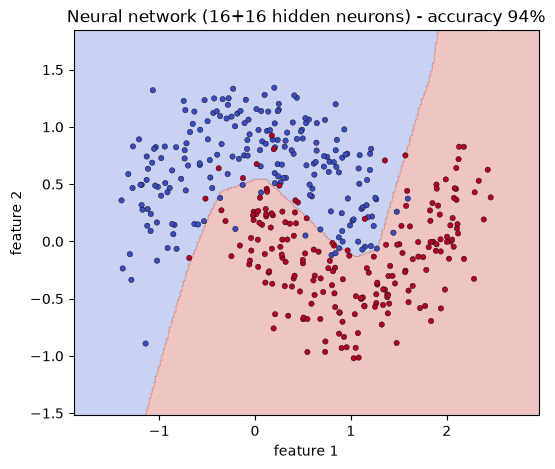

In [15]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=2000, random_state=42)
mlp.fit(X, y)

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(mlp, X, y, ax,
                       f"Neural network (16+16 hidden neurons) - accuracy {mlp.score(X, y):.0%}")
plt.show()

A smooth **curve** that flows between the two moons - no straight-line limitation, no rectangles. The stacked neurons with their little nonlinear squashes bent the boundary into exactly the shape the data needed.

### The picture worth the whole notebook

Same data. Same colors. Same plotting function. Four architectures. The **only** difference between these four panels is the blueprint inside the model:


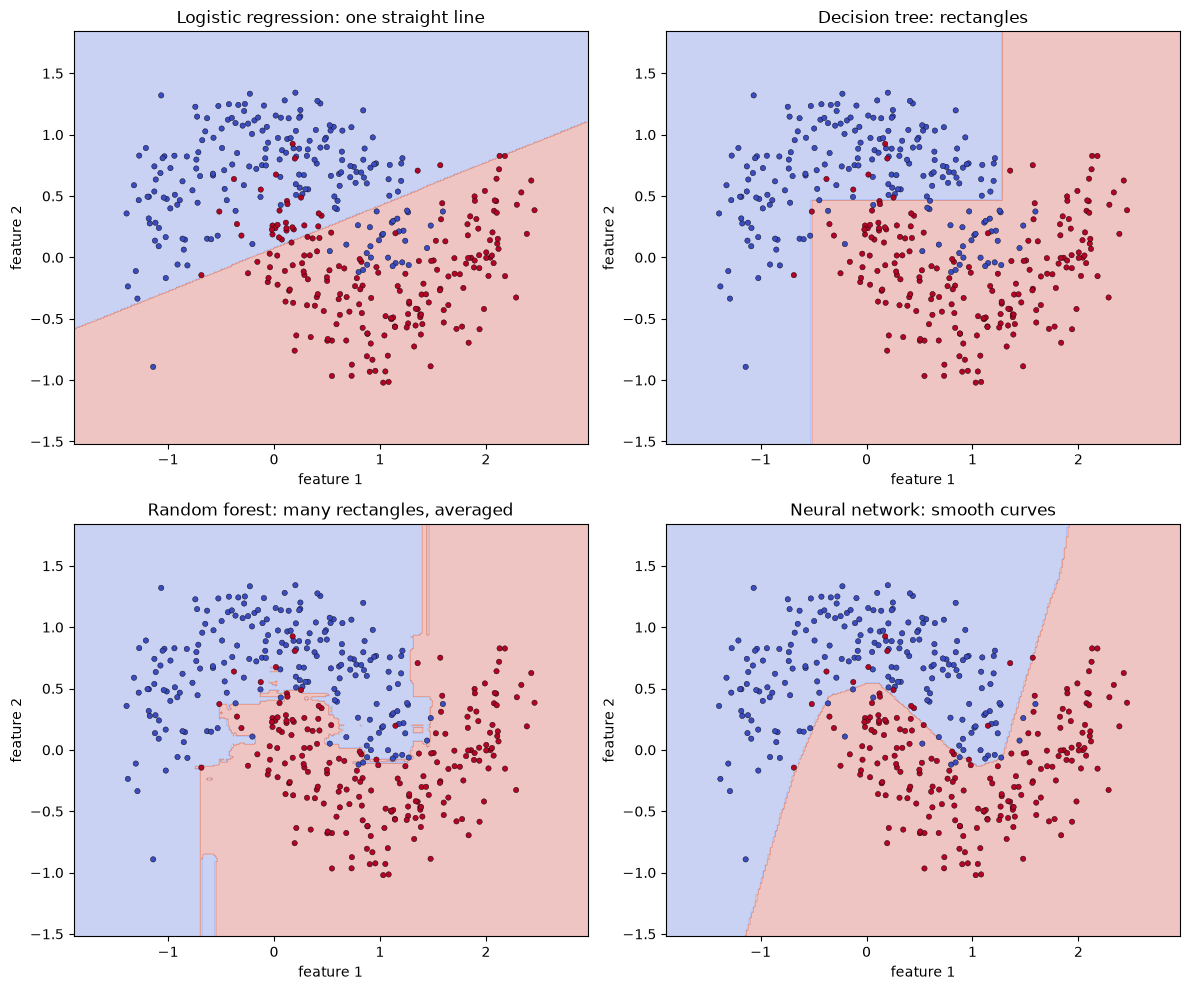

In [16]:
models = [
    (log_reg, "Logistic regression: one straight line"),
    (tree,    "Decision tree: rectangles"),
    (forest,  "Random forest: many rectangles, averaged"),
    (mlp,     "Neural network: smooth curves"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for (model, title), ax in zip(models, axes.ravel()):
    plot_decision_boundary(model, X, y, ax, title)
plt.tight_layout()
plt.show()

Keep this figure in your head. When someone says "which model should I use?", they are really asking *"which of these shapes matches my problem?"*

### 5f. Watching the network learn

During training, `MLPClassifier` records the loss after every pass through the data. Plotting it shows the gradient-descent walk from section 5d happening for real, on thousands of weights at once:


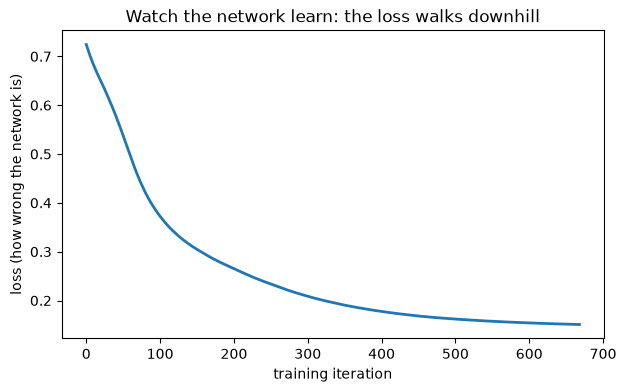

The network trained for 669 iterations before the loss stopped improving.


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mlp.loss_curve_, linewidth=2)
ax.set_xlabel("training iteration")
ax.set_ylabel("loss (how wrong the network is)")
ax.set_title("Watch the network learn: the loss walks downhill")
plt.show()

print(f"The network trained for {mlp.n_iter_} iterations before the loss stopped improving.")

Steep drop at the start (easy wins), then a long slow glide (fine-tuning). Every neural network you will ever train - including the giant ones behind ChatGPT - produces a curve with this shape.

## 6. A taste of real data: handwritten digits

Two moons are great for pictures, but let's try something real: **recognizing handwritten digits**. Scikit-learn ships with `load_digits`: 1,797 images of handwritten digits (0-9), each a tiny **8x8 grayscale image**. No download needed.

First, meet the data:


Images: (1797, 8, 8) -> 1797 images of 8x8 pixels
Labels: (1797,) -> the true digit for each image


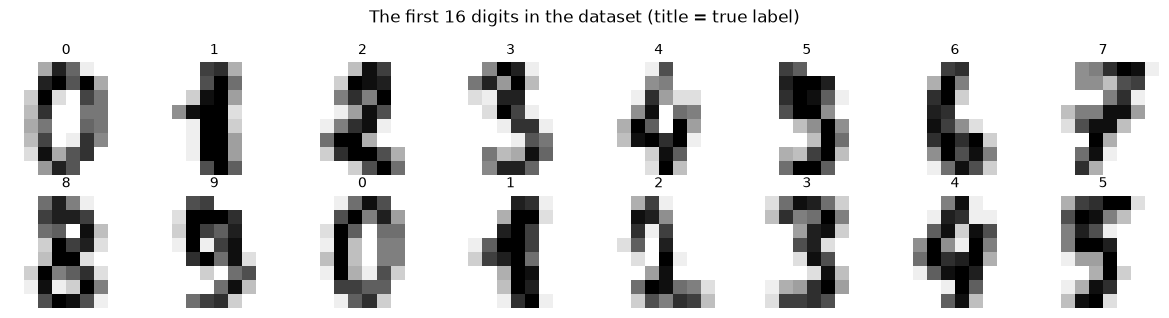

In [18]:
from sklearn.datasets import load_digits

digits = load_digits()
print("Images:", digits.images.shape, "-> 1797 images of 8x8 pixels")
print("Labels:", digits.target.shape, "-> the true digit for each image")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, label in zip(axes.ravel(), digits.images[:16], digits.target[:16]):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(str(label), fontsize=10)
    ax.axis("off")
plt.suptitle("The first 16 digits in the dataset (title = true label)")
plt.tight_layout()
plt.show()

### An image is just a grid of numbers

There is no magic in "the computer sees an image". To a model, an image is a grid of numbers - here, 64 numbers between 0 (white) and 16 (black). Look at one digit both ways at once:


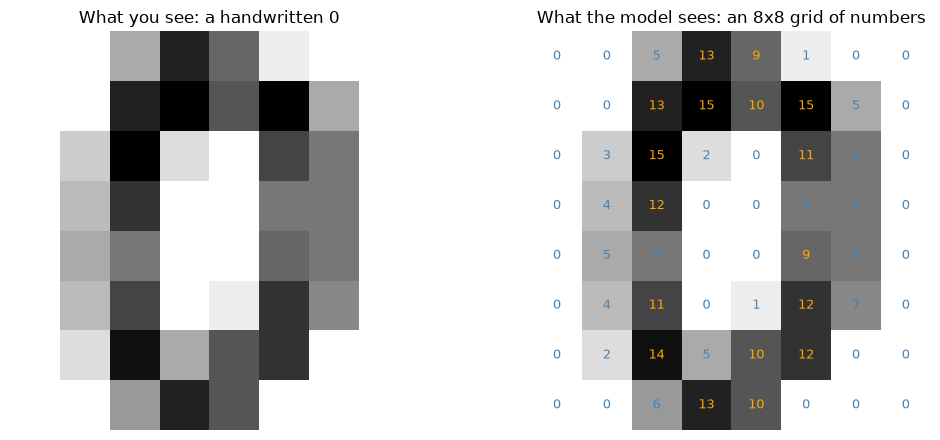

The same digit as the flat list of 64 numbers the model actually receives:
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(digits.images[0], cmap="gray_r")
axes[0].set_title(f"What you see: a handwritten {digits.target[0]}")
axes[0].axis("off")

axes[1].imshow(digits.images[0], cmap="gray_r")
for row in range(8):
    for col in range(8):
        val = int(digits.images[0][row, col])
        axes[1].text(col, row, val, ha="center", va="center",
                     color="orange" if val > 8 else "steelblue", fontsize=9)
axes[1].set_title("What the model sees: an 8x8 grid of numbers")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("The same digit as the flat list of 64 numbers the model actually receives:")
print(digits.images[0].astype(int))

### Training a neural network to read digits

Now we flatten each 8x8 image into 64 input features and train an MLP with one hidden layer of 64 neurons. Exactly like in M2, we hold out a **test set** - data the model never sees during training - to measure honest performance.


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.25, random_state=42, stratify=digits.target)

digit_mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)
digit_mlp.fit(X_train, y_train)

accuracy = digit_mlp.score(X_test, y_test)
print(f"Accuracy on {len(y_test)} unseen digits: {accuracy:.1%}")

Accuracy on 450 unseen digits: 96.2%


About 96% on digits the network has never seen - with the same architecture ideas you built by hand in section 5: weighted sums, ReLU squashes, gradient descent.

### Even the mistakes are understandable

A model that is ~96% right is still wrong a few dozen times. Let's look at the failures - predicted label vs true label:


The network misread 17 of 450 test digits. The first 8:


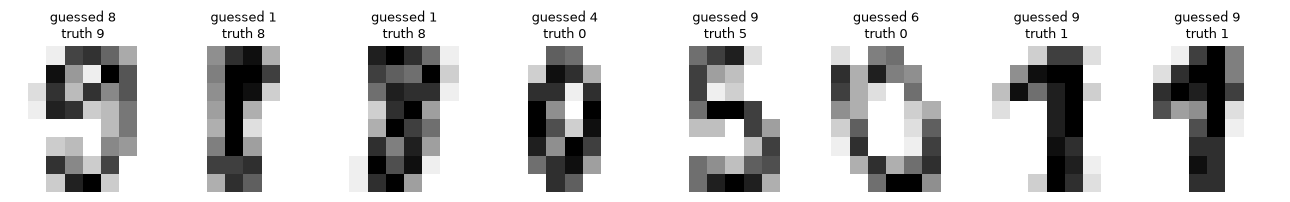

In [21]:
predictions = digit_mlp.predict(X_test)
wrong = np.where(predictions != y_test)[0]
print(f"The network misread {len(wrong)} of {len(y_test)} test digits. The first 8:")

fig, axes = plt.subplots(1, 8, figsize=(13, 2.4))
for ax, idx in zip(axes.ravel(), wrong[:8]):
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"guessed {predictions[idx]}\ntruth {y_test[idx]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Look closely: many of these are genuinely ambiguous - a 4 that does look like a 9, a squished 8 that could be a 1. When a model fails on examples that would also make a human hesitate, that is a sign it learned real patterns rather than noise.

## 7. The specialized architectures tour

The MLP treats its inputs as an unordered list of numbers. That works, but real data has *structure*: pixels have neighbors, words have order. Three famous architectures exploit that structure. This section is theory only - these models need PyTorch or TensorFlow and usually GPUs - but every one of them is built from the parts you now know: neurons, layers, loss, gradient descent.

### CNNs: convolutional neural networks (for images)

Our MLP connected all 64 pixels to every hidden neuron. For a phone photo (12 million pixels) that would be billions of weights - almost all wasted, because a cat's ear looks the same in the top-left as in the bottom-right corner of the photo.

A **CNN** instead learns small **filters** (for example 3x3 pixels) that *slide* across the whole image, reusing the same few weights everywhere:

```
 image           filter slides ->        early layers      deeper layers
 . . . . . .     [f f f]                 detect edges       detect shapes,
 . . . . . .     [f f f]  -> feature     and corners        then whole
 . . . . . .     [f f f]     map                            objects
```

Stacked filters build up understanding: edges, then corners and textures, then shapes, then "cat". Every image model you have used - photo tagging, face unlock, medical scans - is a CNN or a close cousin.

### RNNs and LSTMs: recurrent networks (for sequences)

Sentences, sensor streams, and stock prices are **sequences**: order matters. An **RNN** (recurrent neural network) reads one element at a time and carries a **memory** of what came before:

```
 word1 -> [neuron block] -> word2 -> [same block] -> word3 -> [same block] -> ...
              |                          |                        |
              +----- memory passed ------+------ memory passed ---+
```

The **LSTM** (long short-term memory) is an RNN with learned gates that decide what to remember and what to forget, so it can hold on to context over long sequences.

### Transformers: attention (for language, and now everything)

The architecture behind GPT, BERT, and modern chatbots. Its key trick is **attention**: *every word looks at every other word in the text and decides which ones matter for understanding it*. In "the bank of the river", attention lets "bank" look at "river" and settle its meaning - no step-by-step memory needed, and the whole sentence is processed in parallel.

Two more terms you will keep hearing:

- **Embeddings**: words represented as points in space, where similar words sit close together ("king" near "queen", far from "bicycle"). This is how text becomes numbers a network can process.
- **GPT and BERT** are both transformers - GPT reads left-to-right and generates text; BERT reads in both directions and is used for understanding tasks.

### Out of scope, but not out of reach

Building these requires **PyTorch** or **TensorFlow** (names only for now) and usually GPU hardware. But here is the point of this whole notebook: inside a trillion-parameter transformer you find *exactly* what you built today - weighted sums, activation functions, a loss function, and gradient descent walking downhill. Bigger, not different.

## 8. Choosing an architecture

With the boxes open, choosing becomes rational instead of fashionable:

| Your situation | Reach for | Why |
|---|---|---|
| Tabular / business data (spreadsheets) | Gradient boosting or random forest | They usually win on this data - and need little preprocessing |
| Images | CNN | Filters exploit the "pixels have neighbors" structure |
| Text / language | Transformer (usually pre-trained) | Attention captures word relationships |
| Very small dataset (hundreds of rows) | Linear model or small tree | Complex models memorize small datasets (overfitting) |
| Explainability required (credit, medicine, law) | Linear model or a single shallow tree | You can read the weights or the flowchart aloud |
| Sequences / time series | Boosting with time features, or RNN/LSTM/Transformer | Depends on data size and complexity |

And the honest rule from M2 still stands, now with a deeper reason: **always try the simple thing first and make every fancy model beat that baseline.** A straight line that scores 84% is a fact. A neural network is only worth its complexity if it beats the line *on data it has not seen*.


## 9. From model architecture to system architecture

One last zoom-out, because it sets up the rest of this module. In M2 you saved a trained model to disk with `joblib`. That taught you something important: **a trained model is just a file** - a few kilobytes of learned weights and thresholds.

But a file sitting on your laptop helps nobody. A real product needs a *system* around the model:

```
 [data] --> [training pipeline] --> [model file] --> [API service] --> [applications]
              retrains on a           the .joblib      answers            websites,
              schedule (nightly,      artifact         predictions        apps, other
              weekly, ...)                             24/7               services
```

Two halves, two very different jobs:

- **Training pipeline**: runs occasionally (on a schedule, or when new data arrives), is slow and compute-hungry, and produces one output: a fresh model file.
- **Inference service**: runs constantly, must answer in milliseconds, and only ever *loads* the model file and calls `predict`. ("Inference" is just the fancy word for making predictions with an already-trained model.)

And two ways to serve predictions:

- **Batch prediction**: predict for a whole dataset at once, on a schedule. Example: score all customers for churn risk every night.
- **Real-time API**: one prediction per request, on demand. Example: fraud check while the card payment is processing.

Everything you learned today lives inside the `[model file]` box. **Notebook 2 builds the `[API service]` box and puts it in the cloud** - now that you know what is inside a model, notebook 2 puts one on the internet.

## 10. Key takeaways

- An **architecture** is the blueprint of a model: it fixes what shapes the learned function can take. A model can only learn shapes its architecture allows.
- **Logistic regression** is a weighted scorecard pushed through a sigmoid. Readable, fast - but its boundary is always a straight line.
- **Decision trees** are flowcharts of yes/no questions; their boundaries are rectangles. Deep trees memorize noise (overfitting - you saw it).
- **Random forests** let 100 shuffled trees vote so errors cancel out; **gradient boosting** builds trees in sequence, each fixing the previous team's mistakes. Boosting usually wins on tabular data.
- A **neuron** = weighted sum + activation squash. **Layers** of neurons with nonlinear activations can bend boundaries into almost any shape. Deep learning = many hidden layers.
- Training = minimize a **loss** ("how wrong are we") with **gradient descent** ("feel the slope, step downhill").
- **CNNs** (sliding filters), **RNNs/LSTMs** (memory), and **Transformers** (attention) are specialized layouts of the same parts.
- Choose by data type and constraints - and always make the fancy model beat a simple baseline.
- A trained model is just a file; a product needs a training pipeline and an inference service around it. That is where we go next.

## 11. Practice exercises

Try these yourself before opening the solutions. Everything you need is already imported.

1. **The one-neuron network.** Train an `MLPClassifier` on the moons with `hidden_layer_sizes=(1,)` - a single hidden neuron - and `max_iter=2000, random_state=42`. Plot its decision boundary with our helper. Describe the boundary in one sentence: which model from this notebook does it resemble, and why does that make sense?
2. **Overfit on purpose.** Train a `DecisionTreeClassifier` with no depth limit on the moons. Print its accuracy on the training data, then split the data with `train_test_split` (`test_size=0.3, random_state=42`), retrain on the training part only, and compare training accuracy vs test accuracy. What do the two numbers tell you?
3. **Be the neuron.** By hand (calculator or paper, then check with numpy): a neuron has weights `w = [1.0, -2.0]`, bias `b = 0.5`, and input `x = [3.0, 1.0]`. Compute `z`, then the ReLU output, then the sigmoid output (`1 / (1 + e^-z)`).
4. **Match the scenario to the architecture.** For each scenario pick one: linear model, gradient boosting, CNN, or transformer - and give a one-line reason. (a) Predicting customer churn from a spreadsheet of account data. (b) Detecting cracks in photos of wind-turbine blades. (c) Summarizing customer support emails. (d) A credit-scoring model that a regulator must be able to audit line by line.


## 12. Solutions

### Solution 1: the one-neuron network


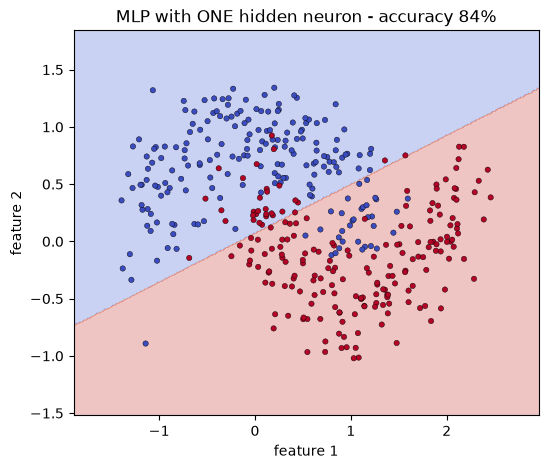

In [22]:
tiny_mlp = MLPClassifier(hidden_layer_sizes=(1,), max_iter=2000, random_state=42)
tiny_mlp.fit(X, y)

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(tiny_mlp, X, y, ax,
                       f"MLP with ONE hidden neuron - accuracy {tiny_mlp.score(X, y):.0%}")
plt.show()

The boundary is essentially a **straight line** - it looks like logistic regression from section 3. That makes sense: one neuron *is* one weighted scorecard, so one hidden neuron can only supply one straight cut for the output to work with. Curves need several neurons whose individual lines combine. The magic of neural networks is in the *many*, not in the neuron.

### Solution 2: overfit on purpose


In [23]:
# An unlimited-depth tree on ALL the data: perfect memorization
full_tree = DecisionTreeClassifier(random_state=42).fit(X, y)
print(f"Unlimited tree, trained and scored on the SAME data: {full_tree.score(X, y):.0%}")

# The honest test: hold out data the tree never sees
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
honest_tree = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
print(f"Training accuracy: {honest_tree.score(X_tr, y_tr):.0%}")
print(f"Test accuracy:     {honest_tree.score(X_te, y_te):.0%}")

Unlimited tree, trained and scored on the SAME data: 100%
Training accuracy: 100%
Test accuracy:     88%


Training accuracy is 100% - the tree memorized every point, including the noise. Test accuracy drops to roughly 85-90%. That gap between training and test performance **is** overfitting, measured. The 100% was never real skill; it was memory.

### Solution 3: be the neuron


In [24]:
w = np.array([1.0, -2.0])
x = np.array([3.0, 1.0])
b = 0.5

z = w @ x + b                      # 1.0*3.0 + (-2.0)*1.0 + 0.5 = 1.5
relu_out = max(0.0, z)             # z is positive, so ReLU passes it through
sigmoid_out = 1 / (1 + np.exp(-z))

print(f"z            = {z}")
print(f"ReLU output    = {relu_out}")
print(f"Sigmoid output = {sigmoid_out:.4f}")

z            = 1.5
ReLU output    = 1.5
Sigmoid output = 0.8176


Step by step: `z = 1.0*3.0 + (-2.0)*1.0 + 0.5 = 3.0 - 2.0 + 0.5 = 1.5`. ReLU keeps positive values, so it outputs **1.5**. Sigmoid squashes 1.5 to `1 / (1 + e^-1.5) = 0.8176` - as a probability, "about 82% confident in class 1".

### Solution 4: match the scenario to the architecture

- **(a) Churn from a spreadsheet -> gradient boosting.** Tabular business data is where boosting (and random forests) consistently win.
- **(b) Cracks in photos -> CNN.** Image data; sliding filters exploit the pixel-neighborhood structure.
- **(c) Summarizing emails -> transformer.** Language in, language out; attention-based models own this space (you would use a pre-trained one, not train your own).
- **(d) Auditable credit scoring -> linear model.** A regulator can read `score = w1*income + w2*debt + ...` line by line. A shallow single tree is a defensible alternative.

---

**Next up:** you now know that a trained model is a file full of learned weights - and you know exactly what those weights do. In **notebook 2** we take such a model file, wrap it in an API service, and put it on the internet with Google Cloud / AWS, so any application in the world can ask it for predictions.
